In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

WEEKLY_PATH = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "vle_weekly_features.csv"
)

PRE_COURSE_PATH = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "vle_pre_course_features.csv"
)

weekly = pd.read_csv(WEEKLY_PATH)
pre_course = pd.read_csv(PRE_COURSE_PATH)

print("주차별 데이터:", weekly.shape)
print("개강 전 데이터:", pre_course.shape)

print("\n주차별 컬럼:")
print(weekly.columns.tolist())

display(weekly.head())
display(pre_course.head())

주차별 데이터: (579438, 16)
개강 전 데이터: (23809, 5)

주차별 컬럼:
['code_module', 'code_presentation', 'id_student', 'week_index', 'total_clicks', 'interaction_rows', 'active_days', 'unique_sites', 'avg_clicks_per_active_day', 'avg_clicks_per_site', 'activity_type_count', 'forumng_clicks', 'quiz_clicks', 'oucontent_clicks', 'resource_clicks', 'other_clicks']


,code_module,code_presentation,id_student,week_index,total_clicks,interaction_rows,active_days,unique_sites,avg_clicks_per_active_day,avg_clicks_per_site,activity_type_count,forumng_clicks,quiz_clicks,oucontent_clicks,resource_clicks,other_clicks
0,AAA,2013J,11391,1,183,30,4,18,45.750000,10.166667,6,18,0,125,8,32
1,AAA,2013J,11391,2,20,4,1,4,20.000000,5.000000,3,0,0,18,0,2
2,AAA,2013J,11391,3,100,15,2,11,50.000000,9.090909,5,35,0,52,1,12
3,AAA,2013J,11391,5,26,8,3,5,8.666667,5.200000,4,2,0,13,0,11
4,AAA,2013J,11391,6,60,12,2,8,30.000000,7.500000,4,23,0,30,0,7


,code_module,code_presentation,id_student,pre_course_clicks,pre_course_interaction_rows
0,AAA,2013J,11391,98,11
1,AAA,2013J,28400,215,55
2,AAA,2013J,30268,102,34
3,AAA,2013J,31604,169,38
4,AAA,2013J,32885,295,66


,week_index,active_student_courses,total_clicks,mean_clicks,median_clicks,mean_active_days
0,1,23658,2013077,85.090752,49.0,3.185645
1,2,23168,1797648,77.591851,45.0,3.124784
2,3,23822,2307080,96.846612,62.0,3.380363
3,4,22135,1663598,75.156901,41.0,3.317597
4,5,21661,1505334,69.495129,39.0,3.288399
5,6,20361,1228901,60.355631,33.0,3.085457
6,7,20237,1350506,66.734496,37.0,3.158769
7,8,19888,1287543,64.739692,37.0,3.138777
8,9,18390,930074,50.574986,25.0,2.902175
9,10,17559,1061916,60.477020,31.0,2.925394


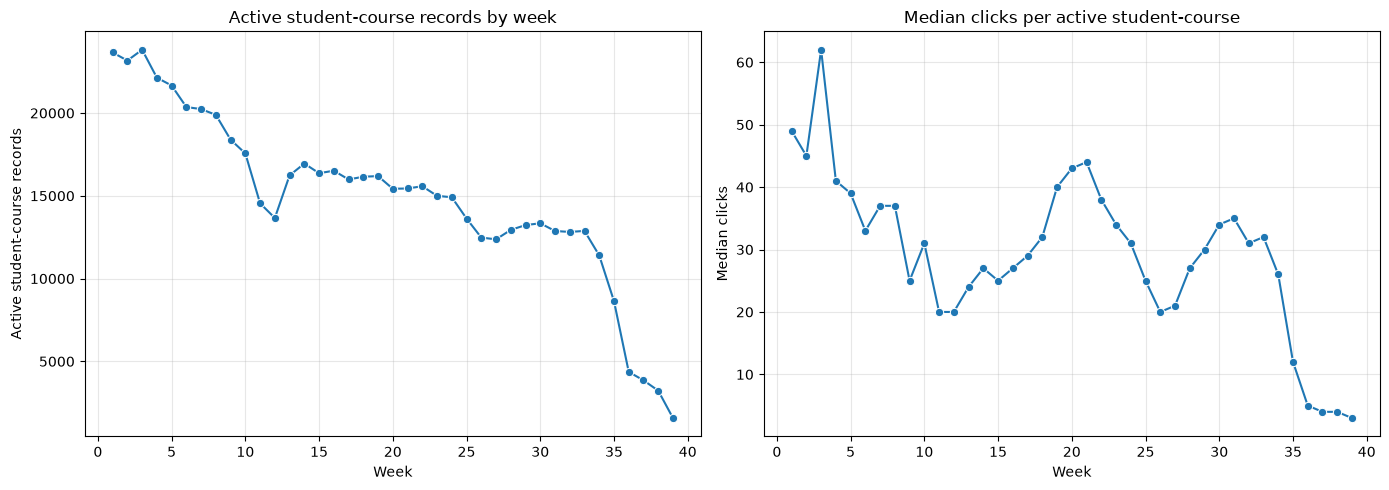

In [2]:
weekly_summary = (
    weekly
    .groupby(
        "week_index",
        as_index=False
    )
    .agg(
        active_student_courses=(
            "id_student",
            "size"
        ),
        total_clicks=(
            "total_clicks",
            "sum"
        ),
        mean_clicks=(
            "total_clicks",
            "mean"
        ),
        median_clicks=(
            "total_clicks",
            "median"
        ),
        mean_active_days=(
            "active_days",
            "mean"
        )
    )
)

display(weekly_summary)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.lineplot(
    data=weekly_summary,
    x="week_index",
    y="active_student_courses",
    marker="o",
    ax=axes[0]
)

axes[0].set_title(
    "Active student-course records by week"
)
axes[0].set_xlabel("Week")
axes[0].set_ylabel("Active student-course records")
axes[0].grid(alpha=0.3)

sns.lineplot(
    data=weekly_summary,
    x="week_index",
    y="median_clicks",
    marker="o",
    ax=axes[1]
)

axes[1].set_title(
    "Median clicks per active student-course"
)
axes[1].set_xlabel("Week")
axes[1].set_ylabel("Median clicks")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

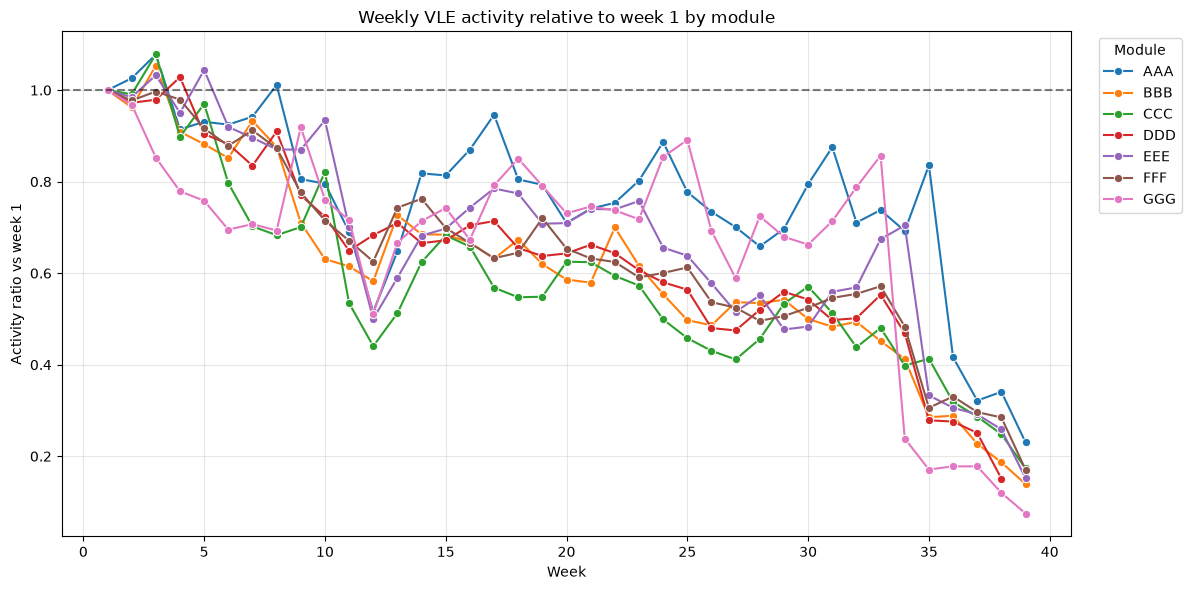

In [3]:
course_week_summary = (
    weekly
    .groupby(
        [
            "code_module",
            "code_presentation",
            "week_index"
        ],
        as_index=False
    )
    .agg(
        active_student_courses=(
            "id_student",
            "size"
        ),
        median_clicks=(
            "total_clicks",
            "median"
        )
    )
)

# 각 강좌·운영 회차의 1주차 활동 학생 수
week1_base = (
    course_week_summary[
        course_week_summary["week_index"] == 1
    ][
        [
            "code_module",
            "code_presentation",
            "active_student_courses"
        ]
    ]
    .rename(
        columns={
            "active_student_courses":
            "week1_active_student_courses"
        }
    )
)

course_week_summary = course_week_summary.merge(
    week1_base,
    on=[
        "code_module",
        "code_presentation"
    ],
    how="left",
    validate="many_to_one"
)

# 1주차 대비 활동 학생·강좌 비율
course_week_summary["activity_ratio_vs_week1"] = (
    course_week_summary["active_student_courses"]
    / course_week_summary[
        "week1_active_student_courses"
    ]
)

# 강좌별 운영 회차의 중앙값
module_week_summary = (
    course_week_summary
    .groupby(
        [
            "code_module",
            "week_index"
        ],
        as_index=False
    )
    .agg(
        median_activity_ratio=(
            "activity_ratio_vs_week1",
            "median"
        )
    )
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=module_week_summary,
    x="week_index",
    y="median_activity_ratio",
    hue="code_module",
    marker="o"
)

plt.axhline(
    1.0,
    color="black",
    linestyle="--",
    alpha=0.5
)

plt.title(
    "Weekly VLE activity relative to week 1 by module"
)
plt.xlabel("Week")
plt.ylabel("Activity ratio vs week 1")
plt.grid(alpha=0.3)
plt.legend(
    title="Module",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

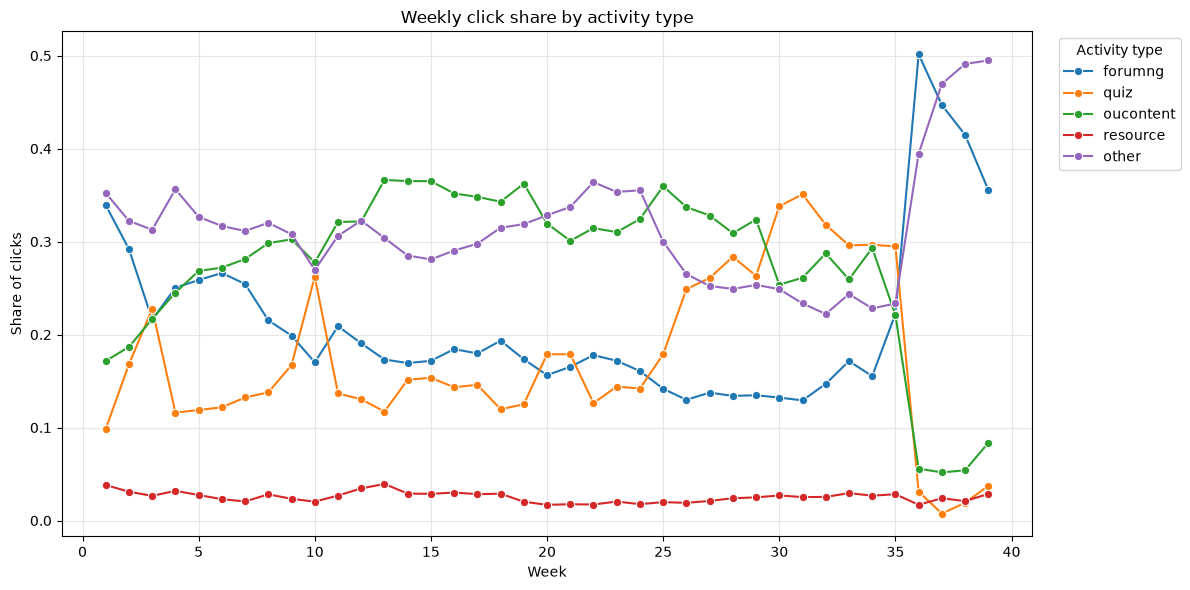

In [4]:
ACTIVITY_COLUMNS = [
    "forumng_clicks",
    "quiz_clicks",
    "oucontent_clicks",
    "resource_clicks",
    "other_clicks"
]

activity_by_week = (
    weekly
    .groupby(
        "week_index",
        as_index=False
    )[ACTIVITY_COLUMNS]
    .sum()
)

activity_by_week["all_activity_clicks"] = (
    activity_by_week[ACTIVITY_COLUMNS]
    .sum(axis=1)
)

for col in ACTIVITY_COLUMNS:
    activity_by_week[f"{col}_ratio"] = (
        activity_by_week[col]
        / activity_by_week["all_activity_clicks"]
    )

ratio_columns = [
    f"{col}_ratio"
    for col in ACTIVITY_COLUMNS
]

activity_ratio_long = (
    activity_by_week[
        ["week_index"] + ratio_columns
    ]
    .melt(
        id_vars="week_index",
        var_name="activity_type",
        value_name="click_ratio"
    )
)

activity_ratio_long["activity_type"] = (
    activity_ratio_long["activity_type"]
    .str.replace(
        "_clicks_ratio",
        "",
        regex=False
    )
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=activity_ratio_long,
    x="week_index",
    y="click_ratio",
    hue="activity_type",
    marker="o"
)

plt.title("Weekly click share by activity type")
plt.xlabel("Week")
plt.ylabel("Share of clicks")
plt.grid(alpha=0.3)
plt.legend(
    title="Activity type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

주차별 total_clicks 분위수:


,quantile,total_clicks
0,0.00,1.0
1,0.25,10.0
2,0.50,31.0
3,0.75,81.0
4,0.90,163.0
5,0.95,237.0
6,0.99,454.0
7,1.00,6999.0


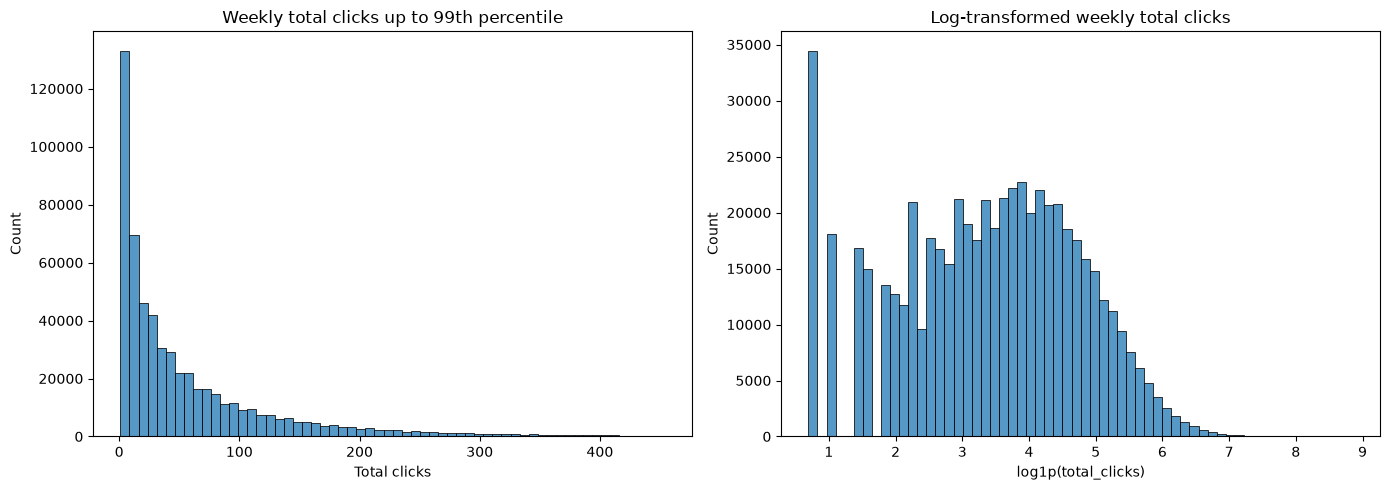

In [5]:
click_quantiles = (
    weekly["total_clicks"]
    .quantile(
        [
            0,
            0.25,
            0.5,
            0.75,
            0.9,
            0.95,
            0.99,
            1.0
        ]
    )
)

print("주차별 total_clicks 분위수:")
display(
    click_quantiles
    .rename("total_clicks")
    .reset_index()
    .rename(columns={"index": "quantile"})
)

click_99 = weekly["total_clicks"].quantile(0.99)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.histplot(
    weekly.loc[
        weekly["total_clicks"] <= click_99,
        "total_clicks"
    ],
    bins=60,
    ax=axes[0]
)

axes[0].set_title(
    "Weekly total clicks up to 99th percentile"
)
axes[0].set_xlabel("Total clicks")

sns.histplot(
    np.log1p(weekly["total_clicks"]),
    bins=60,
    ax=axes[1]
)

axes[1].set_title(
    "Log-transformed weekly total clicks"
)
axes[1].set_xlabel("log1p(total_clicks)")

plt.tight_layout()
plt.show()

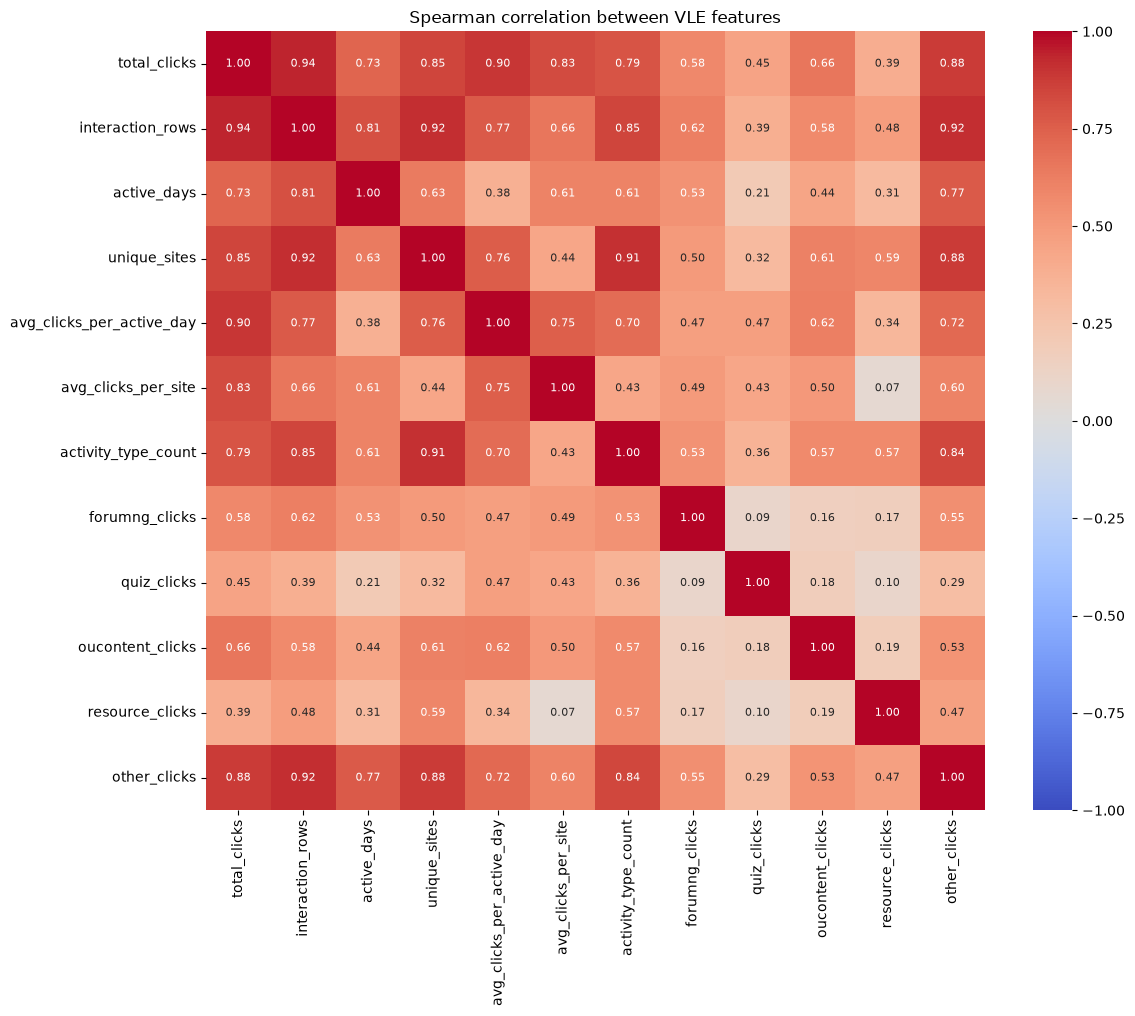

,level_0,level_1,correlation,abs_correlation
1,total_clicks,interaction_rows,0.937542,0.937542
15,interaction_rows,unique_sites,0.919360,0.919360
23,interaction_rows,other_clicks,0.916894,0.916894
42,unique_sites,activity_type_count,0.909502,0.909502
4,total_clicks,avg_clicks_per_active_day,0.896642,0.896642
47,unique_sites,other_clicks,0.879912,0.879912
11,total_clicks,other_clicks,0.879488,0.879488
3,total_clicks,unique_sites,0.850705,0.850705
18,interaction_rows,activity_type_count,0.850452,0.850452
83,activity_type_count,other_clicks,0.839809,0.839809


In [8]:
FEATURE_COLUMNS = [
    "total_clicks",
    "interaction_rows",
    "active_days",
    "unique_sites",
    "avg_clicks_per_active_day",
    "avg_clicks_per_site",
    "activity_type_count",
    "forumng_clicks",
    "quiz_clicks",
    "oucontent_clicks",
    "resource_clicks",
    "other_clicks"
]

# 치우친 분포이므로 Spearman 상관계수 사용
feature_corr = weekly[
    FEATURE_COLUMNS
].corr(method="spearman")

plt.figure(figsize=(12, 10))

sns.heatmap(
    feature_corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True,
    annot_kws={"size": 8}
)

plt.title("Spearman correlation between VLE features")
plt.tight_layout()
plt.show()

upper_mask = np.triu(
    np.ones(
        feature_corr.shape,
        dtype=bool
    ),
    k=1
)

high_corr_pairs = (
    feature_corr
    .where(upper_mask)
    .stack()
    .rename("correlation")
    .reset_index()
)

high_corr_pairs["abs_correlation"] = (
    high_corr_pairs["correlation"].abs()
)

high_corr_pairs = (
    high_corr_pairs
    .sort_values(
        "abs_correlation",
        ascending=False
    )
    .head(15)
)

display(high_corr_pairs)

## VLE EDA 중간 결론

1. 주차가 진행될수록 VLE 활동 학생·강좌 수는 전반적으로 감소했다.

2. 과목별 활동 유지 패턴의 차이가 크므로, 전체 평균만으로 특정 주차를 이탈 골든타임으로 선정하면 안 된다.

3. 11~12주차, 25~26주차 등에서 활동 감소가 확인되지만, 과제 일정과 강좌 운영 구조의 영향일 수 있다.

4. 34주차 이후의 급격한 감소는 일부 강좌의 종료 시점에 따른 데이터 구성 변화일 가능성이 크다.

5. `forumng`, `quiz`, `oucontent` 등 활동 유형별 클릭 비율은 주차에 따라 크게 달라졌다. 특히 퀴즈 클릭은 평가 일정의 영향을 받는 것으로 보인다.

6. 주차별 총 클릭 수는 오른쪽으로 크게 치우친 분포를 보였다.

   - 중앙값: 31
   - 90% 분위수: 163
   - 95% 분위수: 237
   - 99% 분위수: 454
   - 최대값: 6,999

7. 클릭 관련 Feature는 모델링 시 `log1p` 변환을 비교할 필요가 있다.

8. `total_clicks`, `interaction_rows`, `unique_sites`, `activity_type_count` 사이에 높은 상관관계가 확인되었다. 선형 모델에서는 중복 Feature 선택과 규제가 필요하다.

9. 활동 유형별 클릭 수의 합은 `total_clicks`와 같으므로, 선형 모델에서 모든 활동 유형 클릭 수와 총 클릭 수를 동시에 사용하는 것은 피한다.

10. 현재 데이터에는 클릭 기록이 있는 학생·주차만 존재한다. 최종 학생 명단과 Left Join한 뒤 활동하지 않은 학생·주차의 Feature를 0으로 처리해야 한다.

11. 현재 분석은 VLE 활동 분석이며 실제 이탈률 분석이 아니다. 골든타임은 `studentRegistration.date_unregistration`을 이용한 이탈 시점 분석과 함께 결정한다.